# Nonlinear Regression and Forecasting

## A hot cup approaches room temperature

A hot cup cools quickly at first and then more slowly. The useful quantity is its temperature gap above the room:

$$\text{temperature gap}=\text{cup temperature}-\text{room temperature}.$$

Suppose the room is at 20 °C, the cup starts at 80 °C, and 90% of the gap remains after each minute. The initial gap is $80-20=60$ °C. Repeated multiplication gives:

$$\begin{aligned}
\text{after 1 minute: }&20+60\times0.9=74\ ^\circ\mathrm{C},\\
\text{after 2 minutes: }&20+60\times0.9\times0.9=68.6\ ^\circ\mathrm{C},\\
\text{after 3 minutes: }&20+60\times0.9\times0.9\times0.9=63.74\ ^\circ\mathrm{C}.
\end{aligned}$$

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/05_cooling_by_multiplication.png" alt="A temperature gap of 60 degrees becomes 54 and then 48.6 when multiplied by 0.9 each minute." width="640" style="max-width:100%;height:auto;">

Writing $q$ for the fraction of the gap retained each minute makes the same rule shorter:

$$\text{temperature after }t\text{ minutes}=\text{room temperature}+\text{initial gap}\times q^t.$$

The value $q$ lies between 0 and 1. A value closer to 1 means slower cooling. For whole minutes, $q^t$ is repeated multiplication; the same exponential curve also gives temperatures between those times. The 0.9 above is an arithmetic illustration; fitting estimates the initial gap and cooling fraction from the noisy measurements.

Unlike the cart's known feature $t\times t$, the unknown $q$ is raised to a power. This makes the model nonlinear in its unknown parameters.

## Moving a cooling curve toward measured dots

The blue dots are cup temperatures measured from 0 to 12 min. Open teal dots are the current model's predictions at those same times. The vertical gaps determine the mean squared error.

Gradient descent adjusts the parameters repeatedly:

> Next parameter = current parameter − step size × slope of the cost

The slope describes how the cost changes when a parameter increases. For example, a current value of 10, a cost slope of 3, and a step size of 0.2 give $10-0.2\times3=9.4$. A negative cost slope would move the parameter in the opposite direction. A large step can overshoot; a very small one can improve slowly.

The iteration control follows the actual parameter updates; the step-size control changes their size. The displayed curve and cost dot use the same iteration. The program uses scaled parameters to keep the updates comparable; the screen reports the corresponding initial temperature and retained fraction.

Later forecasts use a fixed fitted model chosen from three starting points by the smallest final training cost. Exploring the controls does not change that reference. Several starting points help reveal sensitivity but do not prove that a nonlinear fit has found the global minimum.

,Initial temperature (°C),Gap retained per minute (%),Training RMSE (°C)
Run,,,
1,79.371,88.843,0.437
2,79.371,88.843,0.437
3,79.371,88.843,0.437


Fitted temperature = 20.0 + 59.37 × 0.8884^time


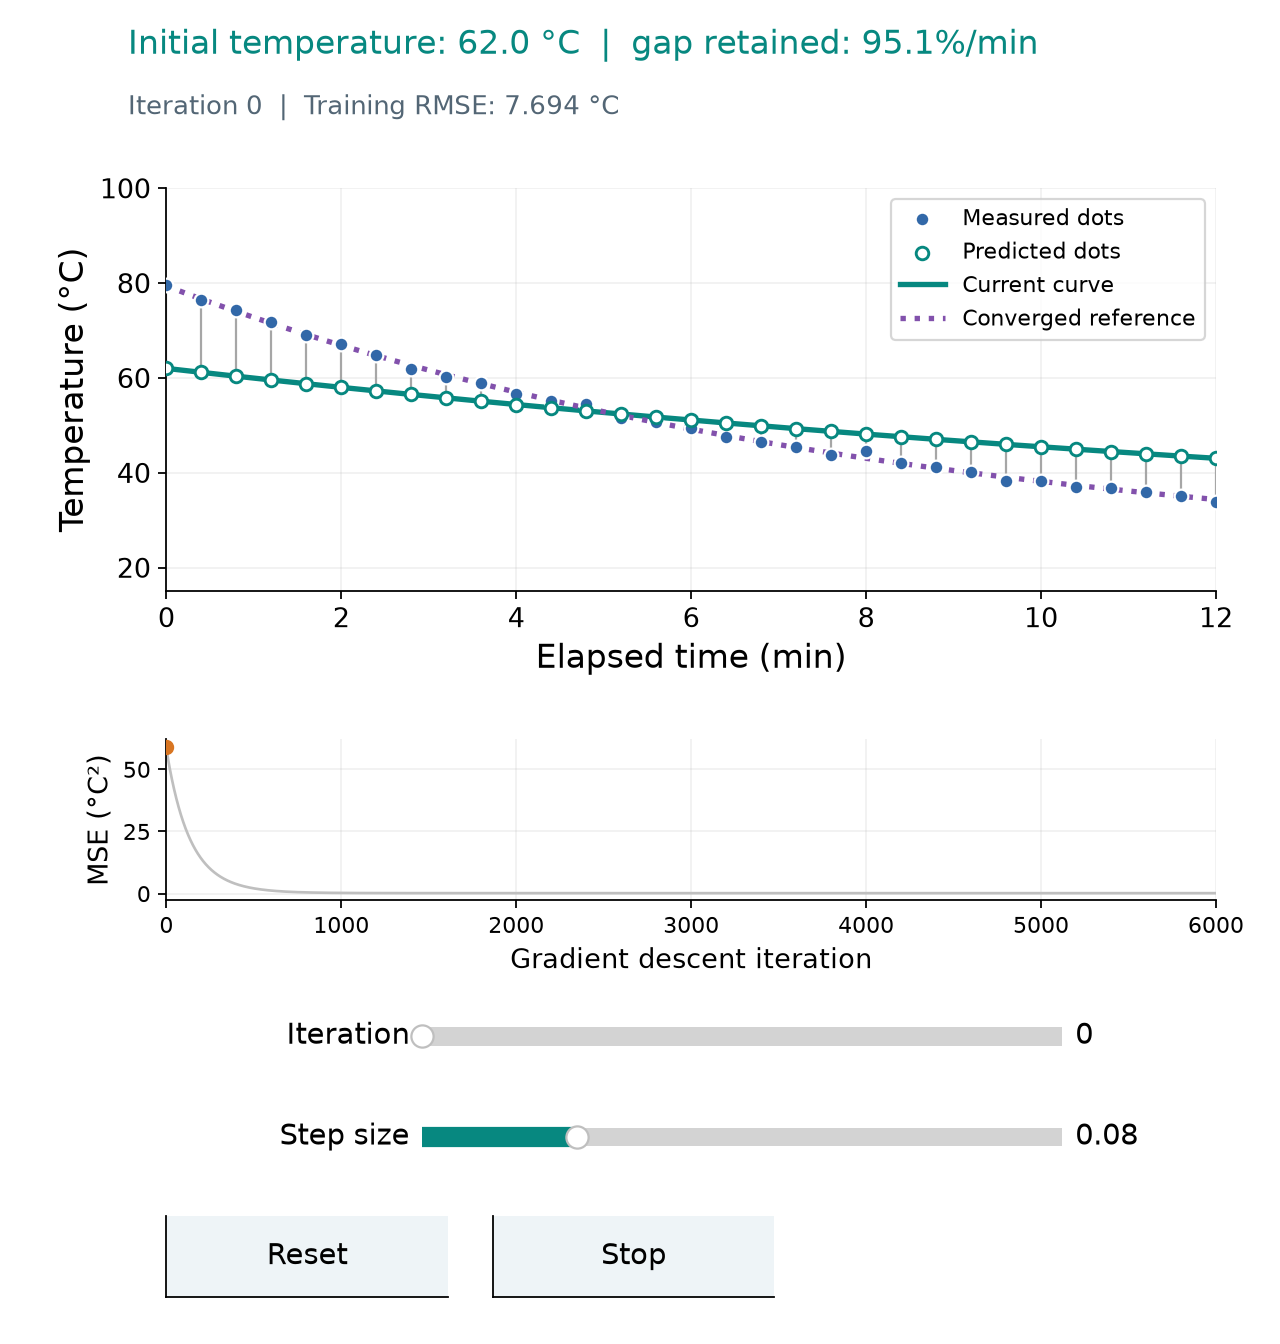

In [1]:
import os
import sys
import io
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

# Bundle the required DejaVu Sans characters for offline browser rendering.
_regression_font = Path(gettempdir()) / "regression-lecture-font.ttf"
_regression_font_data = base64.b64decode("...")
if not _regression_font.exists() or _regression_font.read_bytes() != _regression_font_data:
    _regression_font.write_bytes(_regression_font_data)
font_manager.fontManager.addfont(str(_regression_font))
plt.rcParams.update({
    "font.family": font_manager.FontProperties(fname=str(_regression_font)).get_name(),
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    plt.pause(.04)
            finally:
                self.stop()
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show()

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)


rng_cooling = np.random.default_rng(62)
ambient = 20.0
amplitude_scale, time_scale = 60.0, 12.0
cooling_time_train = np.linspace(0, 12, 31)


def cooling_mean(time):
    return ambient + 60 * np.exp(-0.12 * np.asarray(time))


cooling_temperature_train = cooling_mean(cooling_time_train) + rng_cooling.normal(0, 0.5, 31)
u_train = cooling_time_train / time_scale
z_train = (cooling_temperature_train - ambient) / amplitude_scale


def scaled_cooling_loss_gradient(parameters, u, z):
    a, b = parameters
    decay = np.exp(-b * u)
    error = a * decay - z
    loss = np.mean(error**2)
    gradient = 2 * np.array([np.mean(error * decay),
                             np.mean(error * (-a * u * decay))])
    return loss, gradient


def fit_cooling(initial, step_size=0.08, steps=6000):
    parameters = np.array(initial, dtype=float)
    history = []
    for _ in range(steps):
        loss, gradient = scaled_cooling_loss_gradient(parameters, u_train, z_train)
        history.append([*parameters, loss])
        parameters = parameters - step_size * gradient
    loss, gradient = scaled_cooling_loss_gradient(parameters, u_train, z_train)
    history.append([*parameters, loss])
    return parameters, np.asarray(history), np.linalg.norm(gradient)


cooling_runs = [fit_cooling(initial) for initial in [(0.7, 0.6), (1.2, 2.2), (1.0, 1.0)]]
run_rows = []
for index, (parameters, history, gradient_norm) in enumerate(cooling_runs, start=1):
    run_rows.append({"Run": index, "A (°C)": parameters[0] * amplitude_scale,
                     "k (1/min)": parameters[1] / time_scale,
                     "Train RMSE (°C)": np.sqrt(history[-1, 2]) * amplitude_scale,
                     "Final gradient norm": gradient_norm})
best_run = min(range(len(cooling_runs)), key=lambda j: cooling_runs[j][1][-1, 2])
cooling_parameters, cooling_history, _ = cooling_runs[best_run]
A_fit = cooling_parameters[0] * amplitude_scale
k_fit = cooling_parameters[1] / time_scale
assert A_fit > 0 and k_fit > 0


def predict_cooling(time):
    return ambient + A_fit * np.exp(-k_fit * np.asarray(time))


run_table = pd.DataFrame(run_rows).set_index("Run")
run_table["Final gradient norm"] = run_table["Final gradient norm"].map(lambda value: f"{value:.2e}")
cooling_fit_summary = pd.DataFrame({
    "Initial temperature (°C)": run_table["A (°C)"] + ambient,
    "Gap retained per minute (%)": 100*np.exp(-run_table["k (1/min)"]),
    "Training RMSE (°C)": run_table["Train RMSE (°C)"],
})
display(cooling_fit_summary.round(3))
print(f"Fitted temperature = {ambient:.1f} + {A_fit:.2f} × {np.exp(-k_fit):.4f}^time")

cooling_train_grid = np.linspace(0, 12, 240)
cooling_iteration_cache = {}


def render_cooling_fit(view, iteration, step_size):
    key = round(float(step_size), 4)
    if key not in cooling_iteration_cache:
        cooling_iteration_cache[key] = fit_cooling((.7, .6), step_size=key)[1]
    history = cooling_iteration_cache[key]
    index = int(iteration)
    a, b, loss = history[index]
    amplitude, rate = a * amplitude_scale, b / time_scale
    prediction = ambient + amplitude * np.exp(-rate * cooling_train_grid)
    ax = view.ax
    predicted_train = ambient + amplitude*np.exp(-rate*cooling_time_train)
    ax.vlines(cooling_time_train, predicted_train, cooling_temperature_train, color="0.65", linewidth=1)
    ax.scatter(cooling_time_train, cooling_temperature_train, color=BLUE, s=38,
               edgecolor="white", label="Measured dots", zorder=4)
    ax.scatter(cooling_time_train, predicted_train, facecolors="white", edgecolors=TEAL,
               s=32, linewidths=1.3, label="Predicted dots", zorder=5)
    ax.plot(cooling_train_grid, prediction, color=TEAL, label="Current curve")
    ax.plot(cooling_train_grid, predict_cooling(cooling_train_grid), ":", color=PURPLE,
            label="Converged reference")
    ax.set(xlabel="Elapsed time (min)", ylabel="Temperature (°C)", xlim=(0, 12), ylim=(15, 100))
    ax.legend(loc="upper right", fontsize=10)
    costs = history[:, 2] * amplitude_scale**2
    view.history_ax.plot(np.arange(len(costs)), costs, color="0.75", linewidth=1.2)
    view.history_ax.plot(np.arange(index+1), costs[:index+1], color=TEAL)
    view.history_ax.scatter([index], [costs[index]], color=ORANGE, s=35, zorder=4)
    view.history_ax.set(xlabel="Gradient descent iteration", ylabel="MSE (°C²)", xlim=(0, 6000))
    view.history_ax.yaxis.label.set_size(12)
    view.history_ax.xaxis.label.set_size(12)
    view.history_ax.tick_params(labelsize=10)
    view.status.set_text(f"Initial temperature: {ambient+amplitude:.1f} °C  |  gap retained: {100*np.exp(-rate):.1f}%/min")
    view.detail.set_text(f"Iteration {index}  |  Training RMSE: {np.sqrt(loss)*amplitude_scale:.3f} °C")
    return {"parameters": history[index, :2].copy(), "history": history,
            "prediction": prediction, "loss": loss, "iteration": index,
            "training_prediction": predicted_train}


cooling_fit_demo = RegressionExplorer("cooling_fit", render_cooling_fit, [
    ("iteration", "Iteration", 0, 6000, 0, 25, "%0.0f"),
    ("step_size", "Step size", .01, .30, .08, .01, "%0.2f"),
], history=True)
cooling_fit_demo.start()

## Predicting a later temperature

The orange dot marks the predicted temperature at the chosen future time. Times after 12 min lie beyond the fitting observations. The room remains at 20 °C in this example.

The cooling model, a fitted straight line, and the last measured temperature all use the same past observations. The line keeps falling, while the cooling curve approaches room temperature. Later measured dots are used only to evaluate the predictions.

Keeping past and future separate matches forecasting: future measurements are unavailable when the model is fitted. Mixing them randomly into training would allow information from the future into the prediction.

Future test RMSE in °C; all models use the same past measurements.


,RMSE
Last observation,7.193
Linear regression,22.247
Nonlinear cooling,0.462


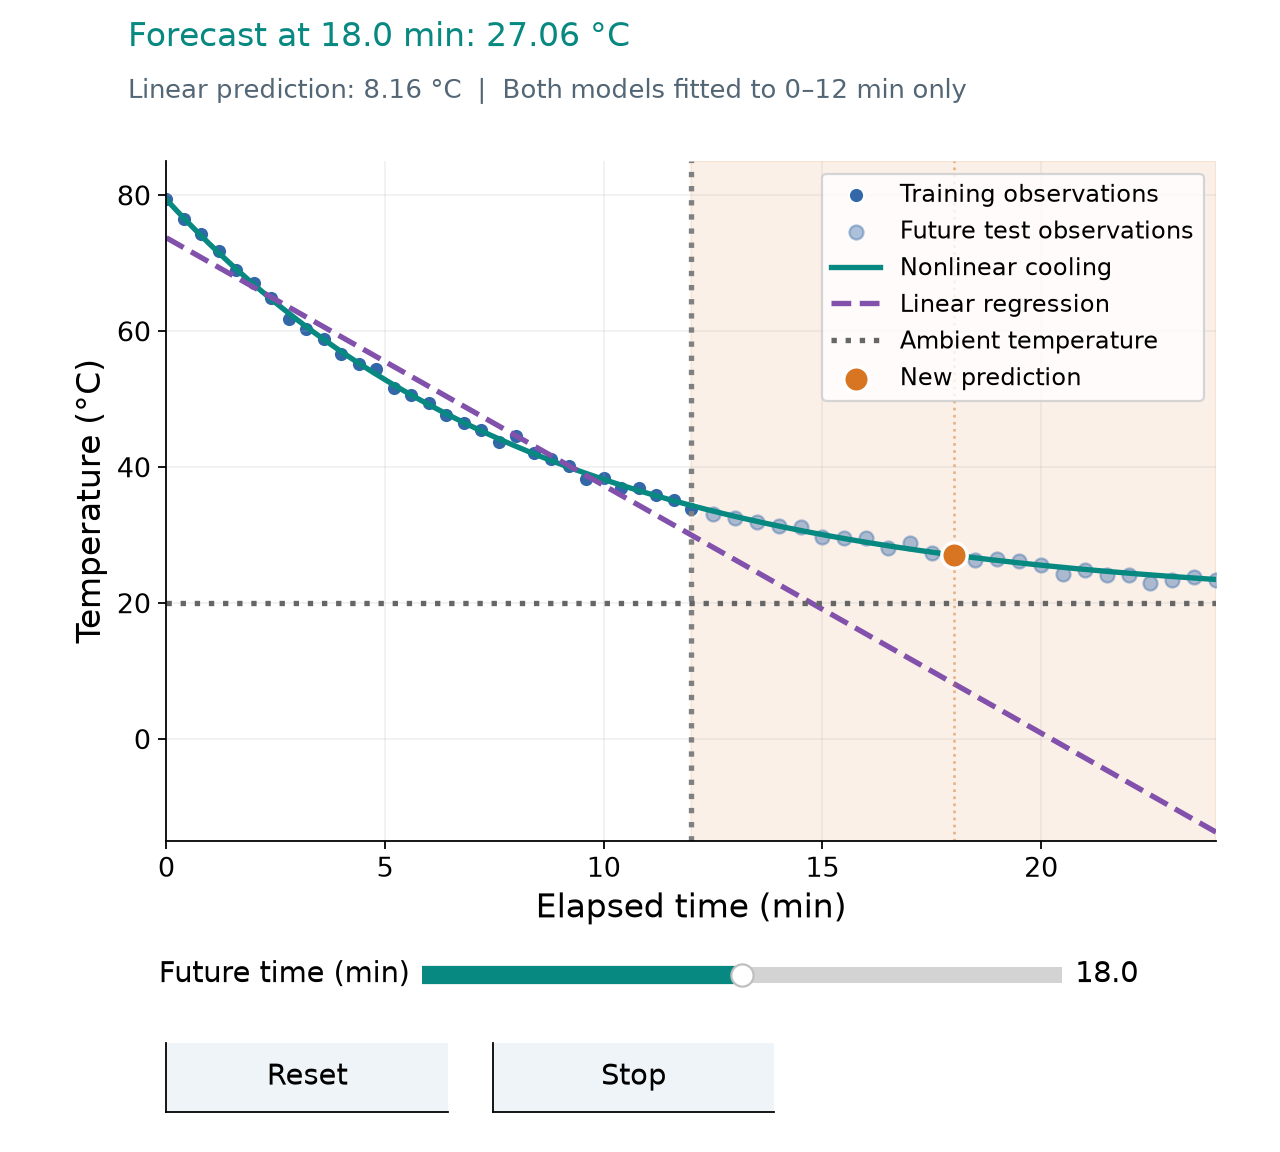

In [2]:
cooling_time_future = np.linspace(12.5, 24, 24)
cooling_temperature_future = cooling_mean(cooling_time_future) + rng_cooling.normal(0, 0.5, 24)
linear_cooling = LinearRegression().fit(cooling_time_train[:, None], cooling_temperature_train)
future_predictions = {
    "Last observation": np.full(len(cooling_time_future), cooling_temperature_train[-1]),
    "Linear regression": linear_cooling.predict(cooling_time_future[:, None]),
    "Nonlinear cooling": predict_cooling(cooling_time_future),
}
print("Future test RMSE in °C; all models use the same past measurements.")
display(pd.DataFrame({name: metrics(cooling_temperature_future, prediction)
                      for name, prediction in future_predictions.items()}).T[["RMSE"]].round(3))

cooling_grid = np.linspace(0, 24, 300)


def render_cooling_forecast(view, forecast_time):
    prediction = float(predict_cooling(forecast_time))
    linear_prediction = float(linear_cooling.predict([[forecast_time]])[0])
    ax = view.ax
    ax.axvspan(12, 24, color=ORANGE, alpha=.10)
    ax.axvline(12, color="0.5", linestyle=":")
    ax.scatter(cooling_time_train, cooling_temperature_train, color=BLUE, edgecolor="white", s=48, label="Training observations")
    ax.scatter(cooling_time_future, cooling_temperature_future, color=BLUE, s=40, alpha=.4,
               label="Future test observations")
    ax.plot(cooling_grid, predict_cooling(cooling_grid), color=TEAL, label="Nonlinear cooling")
    ax.plot(cooling_grid, linear_cooling.predict(cooling_grid[:, None]), "--", color=PURPLE,
            label="Linear regression")
    ax.axhline(ambient, color="0.4", linestyle=":", label="Ambient temperature")
    ax.scatter([forecast_time], [prediction], s=130, color=ORANGE, edgecolor="white", linewidth=1.5,
               label="New prediction", zorder=6)
    ax.set(xlabel="Elapsed time (min)", ylabel="Temperature (°C)", xlim=(0, 24), ylim=(-15, 85))
    ax.axvline(forecast_time, color=ORANGE, linestyle=":", linewidth=1.2, alpha=.5)
    ax.legend(loc="upper right")
    view.status.set_text(f"Forecast at {forecast_time:.1f} min: {prediction:.2f} °C")
    view.detail.set_text(f"Linear prediction: {linear_prediction:.2f} °C  |  Both models fitted to 0–12 min only")
    return {"prediction": prediction, "linear_prediction": linear_prediction, "time": forecast_time}


cooling_forecast_demo = RegressionExplorer("cooling_forecast", render_cooling_forecast, [
    ("forecast_time", "Future time (min)", 12, 24, 18, .1, "%0.1f"),
])
cooling_forecast_demo.start()

## Moving the cup into another room

At 12 min, the cup moves into a room whose temperature is set by the control. Its temperature does not jump immediately; only its later heating or cooling changes.

The blue training dots stay fixed. The teal forecast also stays fixed because the model is not told about the new room. Orange dots show the new future observations. Both scenarios use exactly the same random measurement errors, so the change in prediction error comes from the changed room temperature.

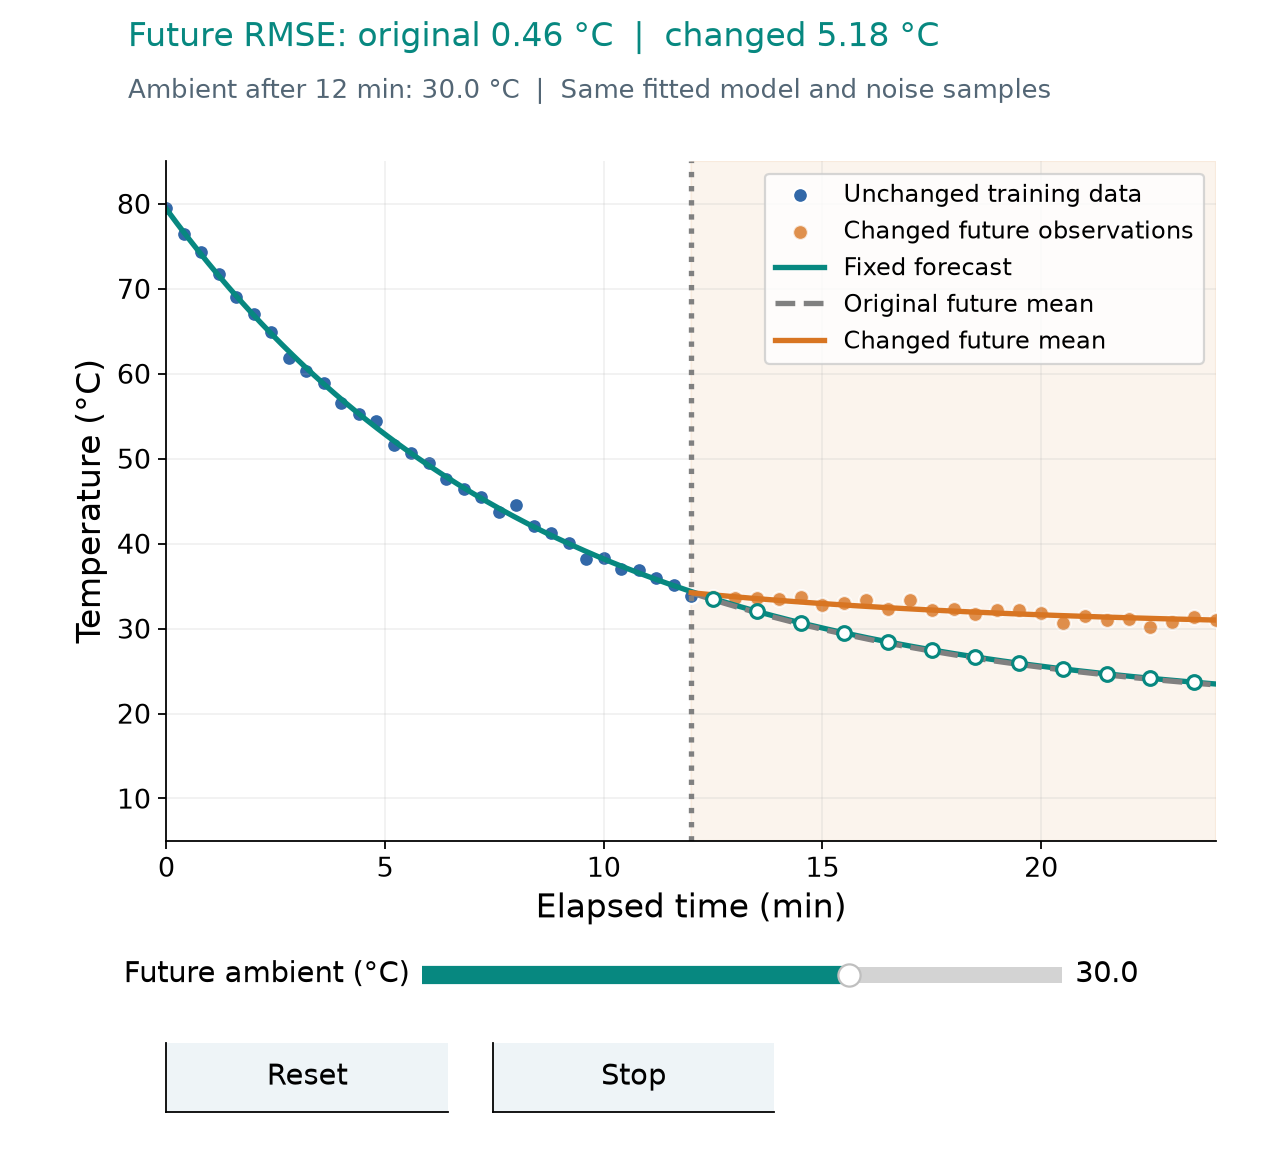

In [3]:
true_temperature_at_move = cooling_mean(12.0)
future_noise = cooling_temperature_future - cooling_mean(cooling_time_future)
frozen_prediction = predict_cooling(cooling_time_future)
original_future_error = metrics(cooling_temperature_future, frozen_prediction)


def render_environment(view, future_ambient):
    changed_mean = future_ambient + (true_temperature_at_move - future_ambient) * np.exp(
        -.12 * (cooling_time_future - 12))
    changed_observations = changed_mean + future_noise
    changed_error = metrics(changed_observations, frozen_prediction)
    future_grid = np.linspace(12, 24, 160)
    changed_curve = future_ambient + (true_temperature_at_move - future_ambient) * np.exp(
        -.12 * (future_grid - 12))
    ax = view.ax
    ax.axvspan(12, 24, color=ORANGE, alpha=.08)
    ax.axvline(12, color="0.5", linestyle=":")
    ax.scatter(cooling_time_train, cooling_temperature_train, color=BLUE, s=45, edgecolor="white",
               label="Unchanged training data")
    ax.scatter(cooling_time_future, changed_observations, color=ORANGE, s=45, alpha=.8, edgecolor="white",
               label="Changed future observations")
    ax.plot(cooling_grid, predict_cooling(cooling_grid), color=TEAL, label="Fixed forecast")
    ax.scatter(cooling_time_future[::2], frozen_prediction[::2], facecolors="white",
               edgecolors=TEAL, s=38, linewidths=1.4, zorder=5)
    ax.plot(future_grid, cooling_mean(future_grid), "--", color="0.5", label="Original future mean")
    ax.plot(future_grid, changed_curve, color=ORANGE, label="Changed future mean")
    ax.set(xlabel="Elapsed time (min)", ylabel="Temperature (°C)", xlim=(0, 24), ylim=(5, 85))
    ax.legend(loc="upper right")
    view.status.set_text(f"Future RMSE: original {original_future_error['RMSE']:.2f} °C  |  changed {changed_error['RMSE']:.2f} °C")
    view.detail.set_text(f"Ambient after 12 min: {future_ambient:.1f} °C  |  Same fitted model and noise samples")
    return {"changed_mean": changed_mean, "observations": changed_observations,
            "prediction": frozen_prediction.copy(), "metrics": changed_error,
            "future_ambient": future_ambient}


environment_demo = RegressionExplorer("environment", render_environment, [
    ("future_ambient", "Future ambient (°C)", 10, 40, 30, .5, "%0.1f"),
])
environment_demo.start()

A model can fit past measurements well and still miss the future when the environment changes. New observations or a model that includes room temperature would provide information missing from the original forecast.

A predicted point estimates an average result, not a guaranteed individual outcome. Nearby observations and a plausible continuation of the process support a prediction; a fitted line alone does not provide an uncertainty interval.